# FlowMatchLY testing

Validation for the conditional flow-matching model of `p(light yield | event params, detector position)`.

Ordered so that failures are diagnosed bottom-up:

1. **Density normalisation** — is the ODE/divergence integration correct at all?
2. **ODE step convergence** — how many integration steps do we actually need?
3. **Marginal consistency** — averaging `p(q|c)` over the data's own contexts must return `p(q)`.
4. **Calibration (PIT)** — the real test: is the *conditional* distribution right?
5. **Per-event conditional PMF** — eyeball one event.
6. **Conditional trends** — does `E[q|c]` track the physics (distance, energy)?
7. **Sliced distributions** — do the shapes match inside bins of a conditioning variable?

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import torch
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pickle
import nugget
from scipy import stats

importlib.reload(nugget.surrogates.FlowMatchLY)
from nugget.surrogates.FlowMatchLY import FlowMatchLY, LightYieldFlowDataset

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


## Config and model

In [3]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

GEOM         = '../other/800_40_40_geom.csv'
TEST_PARQUET = './flow_models/mc_ly_muon_flow_v2_test_samples.parquet'
CHECKPOINT   = './flow_models/best_mc_ly_muon_flow_model_v2.pt'
HISTORY      = './flow_models/mc_ly_muon_flow_v2_training_history.pkl'

N_STEPS = 64      # ODE steps for sampling / density
N_EVAL  = 20000   # rows used for the statistical tests

flow = FlowMatchLY(device=device, domain_size=8000)
flow.load_model(CHECKPOINT)     # restores architecture + normalisers
flow.net.eval()
print('context_dim =', flow.context_dim)
print('target transform: log10(q + u), mu = %.4f, sigma = %.4f'
      % (flow.target_mu, flow.target_sigma))

FlowMatchLY: context_dim=16, width=256, depth=8, params=2,443,009
context_dim = 16
target transform: log10(q + u), mu = 0.3300, sigma = 0.3389


In [4]:
ds = LightYieldFlowDataset(
    flow,
    parquet_path=TEST_PARQUET,
    geometry_csv_path=GEOM,
    # seed=0,
    uniform_energy_zenith=False,   # test on the NATURAL row distribution
    filter_vertex_in_domain=True,
)

# One fixed evaluation batch, reused by every test below.
rng = np.random.default_rng()
rows = rng.integers(0, ds._n_rows, size=N_EVAL)
ctx = flow.build_context(
    torch.from_numpy(ds._point[rows]),
    torch.from_numpy(ds._muon_pos[rows]),
    torch.from_numpy(ds._energy[rows]),
    torch.from_numpy(ds._zenith[rows]),
    torch.from_numpy(ds._azimuth[rows]),
    torch.from_numpy(ds._pmt_direction[rows]),
).to(device)
q_true = ds._count[rows].astype(np.float64)
print(f'{N_EVAL:,} eval rows | q: P(q=1)={np.mean(q_true==1):.4f} '
      f'median={np.median(q_true):.0f} mean={q_true.mean():.2f} max={q_true.max():.0f}')

LightYieldFlowDataset: light yield taken from 'len(times)'
LightYieldFlowDataset: dropped 135433 row(s) with muon vertex outside [5000.0, 5000.0, 5000.0]
LightYieldFlowDataset: 4,805,717 rows, 48,010 events, 4,805,717 samples/epoch
20,000 eval rows | q: P(q=1)=0.6700 median=1 mean=7.10 max=10296


## Training history

The flow-matching loss has a **non-zero floor**: the regression target `x1 - x0` is random
given `x_t`, so the irreducible loss is its conditional variance. Only *relative* changes are
meaningful — there is no "0 is perfect" here.

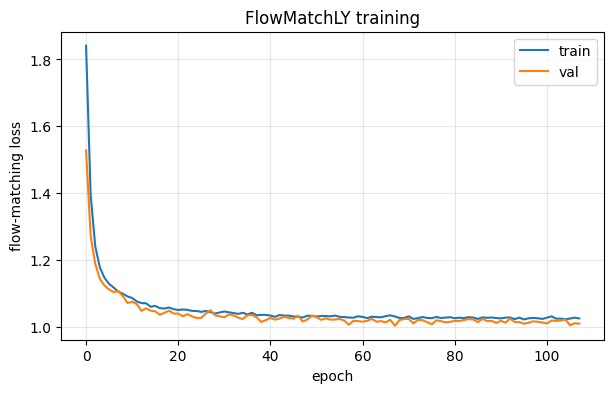

best val: 1.0034255850730374


In [5]:
hist = pickle.load(open(HISTORY, 'rb'))
plt.figure(figsize=(7, 4))
plt.plot(hist['train_loss'], label='train')
if hist.get('val_loss'):
    plt.plot(hist['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('flow-matching loss'); plt.legend()
plt.title('FlowMatchLY training'); plt.grid(alpha=.3); plt.show()
print('best val:', min(hist['val_loss']) if hist.get('val_loss') else 'n/a')

## Test 1 — density normalisation

`integral p(z|c) dz` must be 1. This is the single most important sanity check: a sign error in
the divergence accumulation still produces plausible-looking *samples* while silently corrupting
every likelihood. If this fails, nothing below is trustworthy.

In [6]:
zs = torch.linspace(-8, 8, 1601, device=device, dtype=torch.get_default_dtype()).reshape(-1, 1)
print('integral of p(z|c) dz   (should be 1.000)')
for k in range(5):
    cc = ctx[k:k+1].repeat(len(zs), 1)
    lp = flow.log_prob_z(zs, cc, n_steps=N_STEPS)
    integral = torch.trapezoid(lp.exp().double(), zs.reshape(-1).double()).item()
    print(f'  context {k}: {integral:.5f}')

integral of p(z|c) dz   (should be 1.000)
  context 0: 1.01792
  context 1: 1.02345
  context 2: 1.00722
  context 3: 1.00953
  context 4: 1.03349


## Test 2 — ODE step convergence

How many integration steps are actually needed? Pick the knee, not the largest value.

In [7]:
sub = ctx[:2000]
q_sub = torch.from_numpy(q_true[:2000]).to(device)
ref = flow.log_prob_light_yield(q_sub, sub, n_steps=256).double()
print('n_steps   mean|log p - log p(256 steps)|')
for n in [4, 8, 16, 32, 64, 128, 256]:
    lp = flow.log_prob_light_yield(q_sub, sub, n_steps=n).double()
    print(f'  {n:4d}     {(lp - ref).abs().mean().item():.5f}')

n_steps   mean|log p - log p(256 steps)|
     4     0.23483
     8     0.17215
    16     0.15256
    32     0.13568
    64     0.12834
   128     0.12411
   256     0.13075


## Test 3 — marginal consistency

Averaging `p(q|c)` over the data's own `(θ, x)` must reproduce the unconditional `p(q)`.
This is a **necessary** condition, cheap to check, and catches gross failures — but it is not
sufficient, since it averages over the conditioning. Test 4 is the sharper one.

data   P(q=1)=0.6700  P(q<=2)=0.8024  P(q<=10)=0.9484  median=  1.0  mean=    7.10  q99=     55  max=10296
flow   P(q=1)=0.6582  P(q<=2)=0.8011  P(q<=10)=0.9492  median=  1.0  mean=    5.49  q99=     56  max=8703


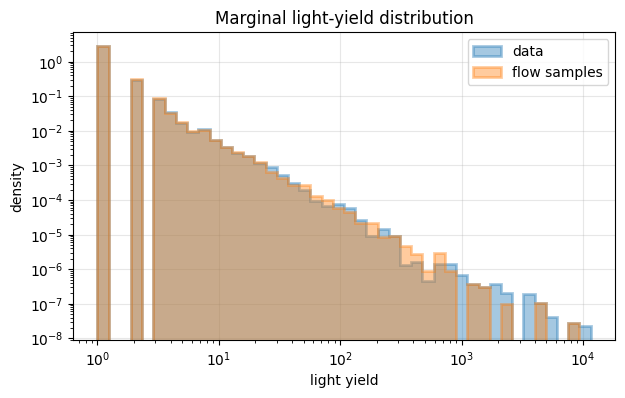

In [8]:
q_samp = flow.sample_light_yield(ctx, n_steps=N_STEPS).cpu().numpy().astype(np.float64)

def summarise(name, a):
    print(f'{name:6s} P(q=1)={np.mean(a==1):.4f}  P(q<=2)={np.mean(a<=2):.4f}  '
          f'P(q<=10)={np.mean(a<=10):.4f}  median={np.median(a):5.1f}  '
          f'mean={a.mean():8.2f}  q99={np.quantile(a,.99):7.0f}  max={a.max():.0f}')
summarise('data', q_true); summarise('flow', q_samp)

bins = np.logspace(0, np.log10(max(q_true.max(), q_samp.max())) + .05, 45)
plt.figure(figsize=(7, 4))
plt.hist(q_true, bins=bins, histtype='step', lw=2, density=True, label='data', fill=True, alpha=.4)
plt.hist(q_samp, bins=bins, histtype='step', lw=2, density=True, label='flow samples', fill=True, alpha=.4)
plt.xscale('log'); plt.yscale('log'); plt.xlabel('light yield'); plt.ylabel('density')
plt.legend()
plt.title('Marginal light-yield distribution')
plt.grid(alpha=.3)
plt.show()

## Test 4 — calibration (PIT)

The real test of the *conditional* distribution.

Because we dequantise (`q̃ = q + u`, `u ~ U(0,1)`), the target is genuinely continuous, so the
ordinary PIT applies: if the model is correct then `F(q̃ | c) ~ Uniform(0,1)`.

`cdf_light_yield` is exact rather than a numerical integral — in 1-D the flow map is monotone,
so the CDF is just the base-space Gaussian CDF of the backward-transported point.

Read the shape of a miscalibrated histogram:
- **U-shaped** → too narrow (over-confident)
- **∩-shaped** → too wide (under-confident)
- **sloped** → biased

PIT mean = 0.5008 (want 0.5),  std = 0.2894 (want 0.2887)
KS vs Uniform(0,1): stat = 0.0090, p = 0.0804


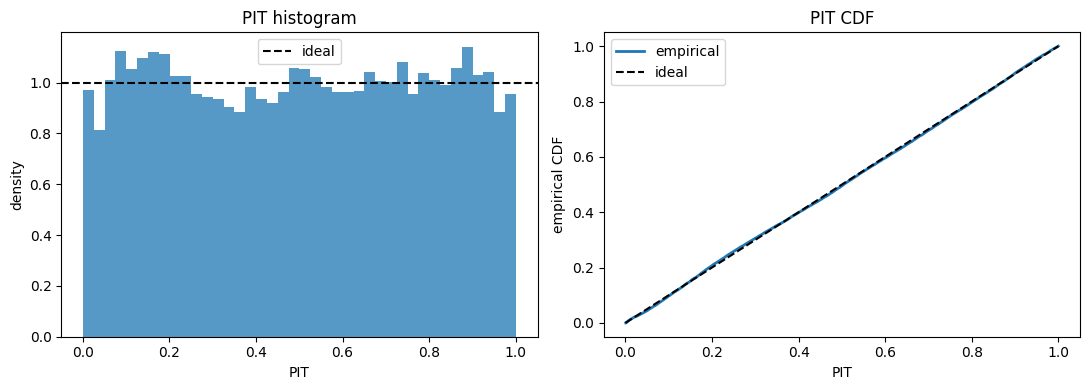

In [9]:
u = torch.rand(len(q_true), device=device, dtype=ctx.dtype)
q_deq = torch.from_numpy(q_true).to(device).to(ctx.dtype) + u
pit = flow.cdf_light_yield(q_deq, ctx, n_steps=N_STEPS).cpu().numpy()

ks = stats.kstest(pit, 'uniform')
print(f'PIT mean = {pit.mean():.4f} (want 0.5),  std = {pit.std():.4f} (want {1/np.sqrt(12):.4f})')
print(f'KS vs Uniform(0,1): stat = {ks.statistic:.4f}, p = {ks.pvalue:.3g}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(pit, bins=40, density=True, color='tab:blue', alpha=.75)
ax[0].axhline(1.0, color='k', ls='--', label='ideal')
ax[0].set_xlabel('PIT'); ax[0].set_ylabel('density'); ax[0].set_title('PIT histogram'); ax[0].legend()
ax[1].plot(np.sort(pit), np.linspace(0, 1, len(pit)), lw=2, label='empirical')
ax[1].plot([0, 1], [0, 1], 'k--', label='ideal')
ax[1].set_xlabel('PIT'); ax[1].set_ylabel('empirical CDF'); ax[1].set_title('PIT CDF'); ax[1].legend()
plt.tight_layout(); plt.show()

### Calibration split by light yield

A model can be calibrated on average while being wrong in the tail — which is exactly where
`E[q]` lives. Check the PIT separately per decade of `q`.

In [10]:
print(f'{"q range":>14}  {"n":>7}  {"PIT mean":>9}  {"KS stat":>8}  {"p":>9}')
for lo, hi in [(1, 2), (2, 10), (10, 100), (100, 1000), (1000, 1e9)]:
    m = (q_true >= lo) & (q_true < hi)
    if m.sum() < 50:
        continue
    k = stats.kstest(pit[m], 'uniform')
    print(f'[{lo:>6.0f},{hi:>7.0f})  {m.sum():>7d}  {pit[m].mean():>9.4f}  '
          f'{k.statistic:>8.4f}  {k.pvalue:>9.2e}')

       q range        n   PIT mean   KS stat          p
[     1,      2)    13399     0.3763    0.1904   0.00e+00
[     2,     10)     5470     0.7317    0.3689   0.00e+00
[    10,    100)     1003     0.8515    0.5622  1.61e-299
[   100,   1000)      111     0.9185    0.6930   9.52e-54


## Test 5 — one event's conditional distribution

`q` is discrete, so the honest object is a **PMF**, not a density. We evaluate
`P(q=k|c) = integral over [k, k+1) of p(q̃|c)` using the exact CDF at the bin edges.

row 4206202: q_true = 107, E_nu = 5e+05 GeV, zenith = 0.996 rad


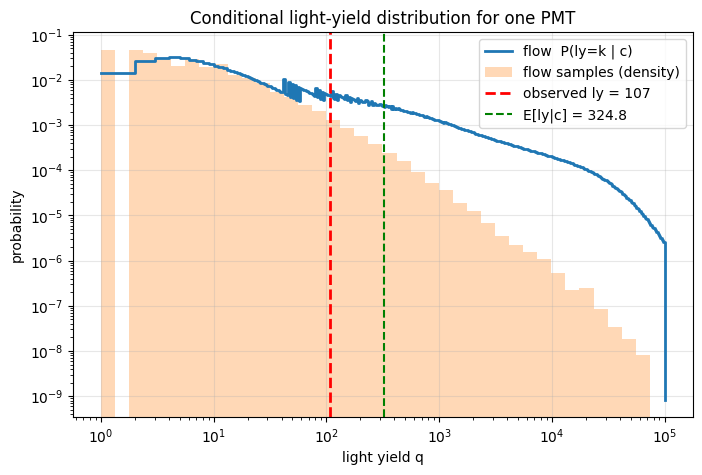

sum of PMF over grid = 0.9999  (<1 means the grid truncates the tail)


In [22]:
# row_i = int(np.argmax(q_true > 1)) if np.any(q_true > 1) else 0
thres_q = 100
test_q = 0
while test_q < thres_q:
      row_i = np.random.randint(0, len(q_true))  # random row for conditional distribution plot
      test_q = q_true[row_i]
c1 = ctx[row_i:row_i+1]
print(f'row {rows[row_i]}: q_true = {q_true[row_i]:.0f}, '
      f'E_nu = {ds._energy[rows[row_i]]:.3g} GeV, zenith = {ds._zenith[rows[row_i]]:.3f} rad')

k_grid = np.unique(np.round(np.logspace(0, np.log10(max(q_true.max(), 1e5)), 400)).astype(int))
edges = torch.tensor(np.concatenate([k_grid, [k_grid[-1] + 1]]), device=device,
                     dtype=ctx.dtype)
cdf_edges = flow.cdf_light_yield(edges, c1.repeat(len(edges), 1), n_steps=N_STEPS).cpu().numpy()
pmf = np.diff(cdf_edges)
pmf = np.clip(pmf, 0, None)

samp = flow.sample_light_yield(c1.repeat(20000, 1), n_steps=N_STEPS).cpu().numpy()
exp_q = float((k_grid * pmf).sum() / max(pmf.sum(), 1e-12))

plt.figure(figsize=(8, 5))
plt.step(k_grid, pmf, where='post', lw=2, label='flow  P(ly=k | c)')
plt.hist(samp, bins=np.logspace(0, np.log10(samp.max() + 1), 40), density=True,
         alpha=.3, label='flow samples (density)')
plt.axvline(q_true[row_i], color='red', ls='--', lw=2, label=f'observed ly = {q_true[row_i]:.0f}')
plt.axvline(exp_q, color='green', ls='--', label=f'E[ly|c] = {exp_q:.1f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('light yield q'); plt.ylabel('probability')
plt.legend(); plt.title('Conditional light-yield distribution for one PMT'); plt.grid(alpha=.3)
plt.show()

print(f'sum of PMF over grid = {pmf.sum():.4f}  (<1 means the grid truncates the tail)')

## Test 6 — conditional trends

Does `E[q|c]` follow the physics? Compare the model's conditional mean against the binned
empirical mean, as a function of perpendicular distance to the track and of energy.

Note `E[q]` is the **least reliable** thing to ask for: the distribution is tail-dominated, so
this plot has large error bars in the data itself. `exp(E[log q])` is far more stable.

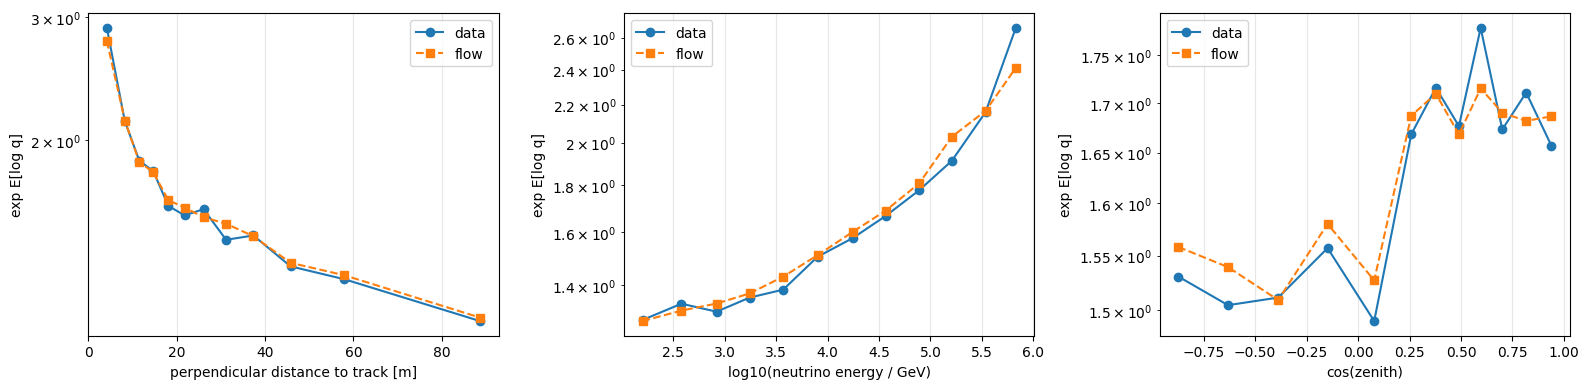

In [ ]:
pts, vert = ds._point[rows], ds._muon_pos[rows]
zen, azi = ds._zenith[rows], ds._azimuth[rows]
u_dir = np.stack([np.sin(zen)*np.cos(azi), np.sin(zen)*np.sin(azi), np.cos(zen)], 1)
rel = pts - vert
along = (rel * u_dir).sum(1)
perp = np.linalg.norm(rel - along[:, None] * u_dir, axis=1)
logE = np.log10(ds._energy[rows])

n_s = 128
rep = ctx.repeat_interleave(n_s, 0)
q_mc = flow.sample_light_yield(rep, n_steps=N_STEPS).reshape(len(q_true), n_s).cpu().numpy()
model_geo = np.exp(np.log(np.clip(q_mc, 1, None)).mean(1))   # exp E[log q]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, x, lab in [(ax[0], perp, 'perpendicular distance to track [m]'),
                  (ax[1], logE, 'log10(neutrino energy / GeV)'),
                  (ax[2], np.cos(zen), 'cos(zenith)')]:
    qs = np.quantile(x, np.linspace(0, 1, 13)) # get 12 bins with equal number of rows
    idx = np.digitize(x, qs[1:-1]) # get bin index for each row
    cx = [x[idx == b].mean() for b in range(12) if (idx == b).sum() > 20] # get mean x for each bin
    dy = [np.exp(np.log(np.clip(q_true[idx == b], 1, None)).mean()) 
          for b in range(12) if (idx == b).sum() > 20]
    my = [np.exp(np.log(np.clip(model_geo[idx == b], 1, None)).mean())
          for b in range(12) if (idx == b).sum() > 20]
    a.plot(cx, dy, 'o-', label='data')
    a.plot(cx, my, 's--', label='flow')
    a.set_xlabel(lab); a.set_ylabel('exp E[log q]'); a.set_yscale('log')
    a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Test 7 — sliced distributions

Test 3 could pass while every conditional is wrong in compensating ways. Slice by a
conditioning variable and compare the *shapes* inside each slice.

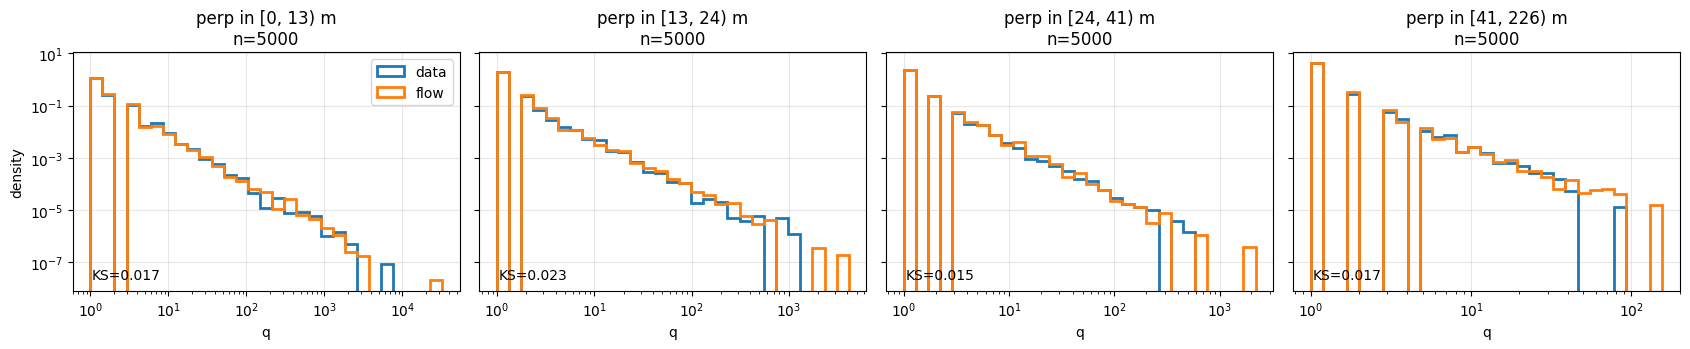

: 

In [ ]:
qs = np.quantile(perp, [0, .25, .5, .75, 1.0])
fig, ax = plt.subplots(1, 4, figsize=(17, 3.6), sharey=True)
for i in range(4):
    m = (perp >= qs[i]) & (perp < qs[i+1] if i < 3 else perp <= qs[i+1])
    if m.sum() < 100:
        continue
    b = np.logspace(0, np.log10(max(q_true[m].max(), q_samp[m].max())) + .05, 30)
    ax[i].hist(q_true[m], bins=b, histtype='step', lw=2, density=True, label='data')
    ax[i].hist(q_samp[m], bins=b, histtype='step', lw=2, density=True, label='flow')
    ax[i].set_xscale('log'); ax[i].set_yscale('log')
    ax[i].set_title(f'perp in [{qs[i]:.0f}, {qs[i+1]:.0f}) m\nn={m.sum()}')
    ax[i].set_xlabel('q'); ax[i].grid(alpha=.3)
    ks = stats.ks_2samp(q_true[m], q_samp[m])
    ax[i].text(.05, .05, f'KS={ks.statistic:.3f}', transform=ax[i].transAxes)
ax[0].set_ylabel('density'); ax[0].legend()
plt.tight_layout(); plt.show()

## Summary checklist

| test | pass condition |
|---|---|
| 1 normalisation | integrals within ~1% of 1.0 |
| 2 ODE steps | log-prob flat beyond the chosen `N_STEPS` |
| 3 marginal | `P(q=1)`, quantiles, and the histogram overlay agree |
| 4 PIT | flat histogram, diagonal CDF, no strong slope or U-shape |
| 4b PIT by decade | no decade badly skewed (watch the tail) |
| 5 single event | PMF sums to ~1 over the grid; observed `q` in a plausible region |
| 6 trends | flow tracks the data curve vs distance and energy |
| 7 slices | shapes agree inside each slice, small KS |
| 10 joint | light-yield contours overlap; context panels identical (control) |

A **U-shaped PIT** with a good marginal is the classic signature of a model that has learned
`p(q)` but not the conditioning — check that the context is actually reaching the network.

## Test 8 — NLL landscape scan

Scan the event parameters and plot `-sum_i log p(q_i | theta, x_i)`, the same landscape
`llr_testing.ipynb` produces for LLRnet — but here each term is a **properly normalised**
log-likelihood rather than a log-ratio.

The two are equivalent up to a constant: the LLR differs from `log p(q|theta,x)` by
`+ log p_marg(q)`, which does not depend on `theta` and therefore cancels once the landscape
is shifted to `NLL = 0` at its minimum. So the *shape* is directly comparable to the LLRnet
plot, while the absolute scale here is meaningful too.

Two things the flow path does differently:

- The dequantisation `q~ = q + u` is drawn **once** (seeded by `flow_seed`) and reused at every
  grid point, so the landscape is smooth instead of carrying fresh `U(0,1)` noise per hypothesis.
- Cost scales with `flow_n_steps` x grid points, since each hypothesis needs an ODE solve.
  Start at `flow_n_steps=16` for a quick look and raise it once the shape looks sensible.

### 8a — real event from the parquet

`parquet_dataset` takes the flow's own `LightYieldFlowDataset`. Detector positions and the
observed light yields come from one real event; only the hypothesis parameters are varied.
Pass `llrnet=None` — the flow supplies `device` / `domain_size` / `add_pmt_direction`.

plot_nll_landscape: using parquet event 6718 with 200/206 hit PMT(s).
  neutrino energy : 1.03e+04 GeV
  zenith          : 0.9411 rad (cos = 0.5889)
  azimuth         : 1.0101 rad
  muon vertex     : (448.85, -585.70, 474.39) m
  light yields    : min 1.0, max 244.0, sum 2671.0
NLL landscape (zenith vs azimuth): processed 50/625 landscape points
NLL landscape (zenith vs azimuth): processed 100/625 landscape points
NLL landscape (zenith vs azimuth): processed 150/625 landscape points
NLL landscape (zenith vs azimuth): processed 200/625 landscape points
NLL landscape (zenith vs azimuth): processed 250/625 landscape points
NLL landscape (zenith vs azimuth): processed 300/625 landscape points
NLL landscape (zenith vs azimuth): processed 350/625 landscape points
NLL landscape (zenith vs azimuth): processed 400/625 landscape points
NLL landscape (zenith vs azimuth): processed 450/625 landscape points
NLL landscape (zenith vs azimuth): processed 500/625 landscape points
NLL landscape (zenith 

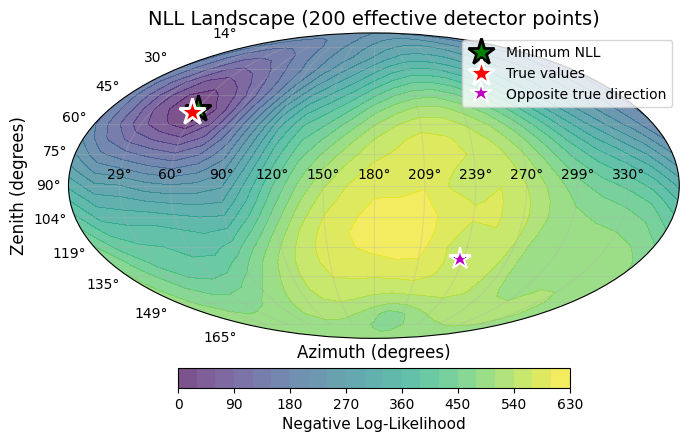

In [19]:
importlib.reload(nugget.utils.vis_tools)

result = nugget.utils.vis_tools.plot_nll_landscape(
    llrnet=None,
    flow_model=flow,
    signal_sampler=None,             # not needed: the event comes from the parquet
    signal_surrogate_func=None,      # not needed either
    event_labels=['position', 'energy', 'direction'],
    param_names=['zenith', 'azimuth'],
    param_ranges={'energy': (1e2, 1e6), 'zenith': (0, np.pi), 'azimuth': (0, 2*np.pi)},
    n_points=25,
    figsize=(7, 5),
    use_mollweide=True,
    plot_opposite_direction_true_params=True,
    parquet_dataset=ds,              # the LightYieldFlowDataset built above
    # parquet_event_seed=1,
    num_detector_points=200,
    min_detector_points=20,
    flow_n_steps=16,                 # raise once the shape looks right
    flow_seed=0,
    progress_print_every_n_points=50,
)

### 8b — 1-D energy scan

A 1-D slice is the easiest place to see whether the minimum actually sits at the true value.

plot_nll_landscape: using parquet event 2819 with 71/71 hit PMT(s).
  neutrino energy : 548.3 GeV
  zenith          : 1.0549 rad (cos = 0.4933)
  azimuth         : 1.1252 rad
  muon vertex     : (150.40, 468.31, -2.26) m
  light yields    : min 1.0, max 7.0, sum 121.0


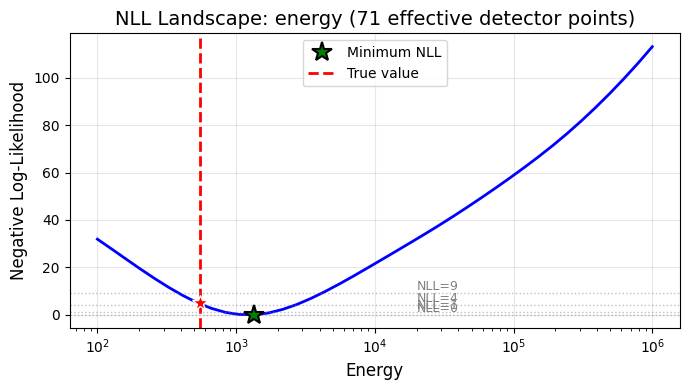

In [30]:
result_e = nugget.utils.vis_tools.plot_nll_landscape(
    llrnet=None,
    flow_model=flow,
    signal_sampler=None,
    signal_surrogate_func=None,
    event_labels=['position', 'energy', 'direction'],
    param_names=['energy'],
    param_ranges={'energy': (1e2, 1e6)},
    n_points=40,
    figsize=(7, 4),
    parquet_dataset=ds,
    # parquet_event_seed=1,
    num_detector_points=500,
    min_detector_points=100,
    flow_n_steps=32,
    flow_seed=0,
)

### 8c — self-consistency scan (no parquet)

With **no** `parquet_dataset`, the flow generates its own pseudo-data: the true event comes
from `signal_sampler`, detector points are sampled as usual, and each light yield is *drawn
from the flow itself* at the true parameters.

This separates two failure modes:

- minimum **at** the truth here but **off** on real data → the flow is self-consistent but has
  not learned the real physics;
- minimum **off** the truth even here → the likelihood machinery itself is wrong (feature
  construction, ODE integration, or the conditioning is not reaching the network).

Needs a `signal_sampler`; `signal_surrogate_func` is ignored because the flow replaces it.

NLL landscape (zenith vs azimuth): processed 50/625 landscape points
NLL landscape (zenith vs azimuth): processed 100/625 landscape points
NLL landscape (zenith vs azimuth): processed 150/625 landscape points
NLL landscape (zenith vs azimuth): processed 200/625 landscape points
NLL landscape (zenith vs azimuth): processed 250/625 landscape points
NLL landscape (zenith vs azimuth): processed 300/625 landscape points
NLL landscape (zenith vs azimuth): processed 350/625 landscape points
NLL landscape (zenith vs azimuth): processed 400/625 landscape points
NLL landscape (zenith vs azimuth): processed 450/625 landscape points
NLL landscape (zenith vs azimuth): processed 500/625 landscape points
NLL landscape (zenith vs azimuth): processed 550/625 landscape points
NLL landscape (zenith vs azimuth): processed 600/625 landscape points
NLL landscape (zenith vs azimuth): processed 625/625 landscape points


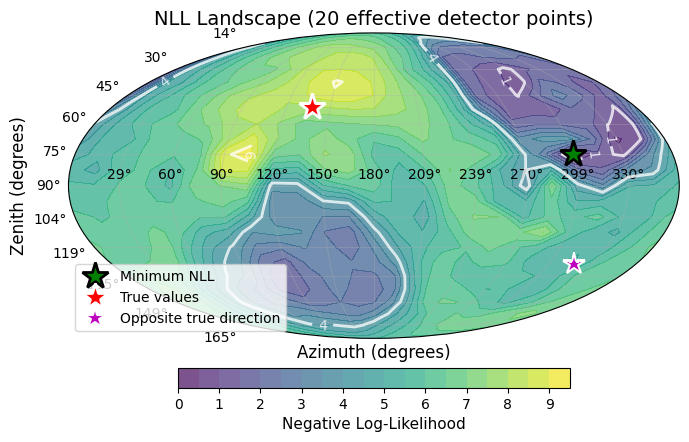

In [32]:
signal_sampler = nugget.samplers.cyl_sampler.CylinderSampler(
    device=device,
    event_type='signal',
    domain_size=2000,
    E_min=1e2,
    E_max=1e6,
    energy_dist='log_uniform',
    find_exact_intersection=False,
    box_intersection=False,
    uniform_zenith_sampling=True,
    random_position_along_ray=True,
)

result_self = nugget.utils.vis_tools.plot_nll_landscape(
    llrnet=None,
    flow_model=flow,
    signal_sampler=signal_sampler,
    signal_surrogate_func=None,      # replaced internally by a flow sampler
    event_labels=['position', 'energy', 'direction'],
    param_names=['zenith', 'azimuth'],
    param_ranges={'energy': (1e2, 1e6), 'zenith': (0, np.pi), 'azimuth': (0, 2*np.pi)},
    n_points=25,
    figsize=(7, 5),
    use_mollweide=True,
    plot_opposite_direction_true_params=True,
    num_detector_points=200,
    min_detector_points=20,
    min_detector_response=1.0,
    max_detector_resample_attempts=100000,
    flow_n_steps=16,
    flow_seed=0,
    # Only used when the flow was trained with add_pmt_direction=True: real PMT
    # directions exist only for parquet events, so a fixed one is used for both
    # generating and evaluating the pseudo-data (keeping the test self-consistent).
    flow_pmt_direction=(0.0, 0.0, -1.0),
    progress_print_every_n_points=50,
)

### Reading the scan

- **Minimum at the true parameters** — the conditioning is informative and correctly oriented.
- **Minimum at the *opposite* direction** (the dashed marker from
  `plot_opposite_direction_true_params`) — a track and its reverse light the same PMTs, so this
  degeneracy is partly physical. It becomes a red flag if the opposite point is *deeper* than
  the truth.
- **Flat landscape** — the context is not reaching the velocity network. Cross-check Test 4:
  a flat scan together with a U-shaped PIT means the model learned `p(q)` and ignored `c`.
- **Ragged / noisy landscape** — raise `flow_n_steps`. If it persists, confirm `flow_seed` is
  set so the dequantisation is being held fixed across grid points.

## Test 9 — 3-D light-yield map, data vs. flow samples

Pick one random event and plot the total light yield per detector module (DOM), side by side:
left from the real parquet data, right from the flow model **sampled at every PMT of the full
detector geometry** (all strings x DOMs x 16 PMTs) using that event's true parameters.

Each DOM has 16 PMTs, so the plotted quantity is the **summed** light yield of all PMTs at
that DOM, aggregated after sampling.

**Read this plot with the hurdle-model caveat in mind.** This flow was trained only on
`q >= 1` rows -- it has never seen "no light reaches this PMT" and `sample_light_yield` floor-
clamps every draw to at least 1. So sampling across the *whole* geometry will report some
light at essentially every one of the ~56,500 DOMs, whereas the real data (right... left panel)
only ever records the PMTs that were actually hit -- typically a few hundred out of ~900,000.
**This is expected, not a bug**: it is exactly the gap a hit/no-hit hurdle classifier (trained
separately, as discussed earlier) is meant to close. What this plot *does* check is whether the
flow's light-yield magnitude decays with distance from the track the way real light does, even
though it cannot yet express an exact zero.

Sampling ~900,000 PMTs means ~220x more forward passes than Test 5-8 use, so this cell runs in
batches and uses fewer ODE steps by default (`FULL_GEOM_N_STEPS`) to keep it tractable — raise
it once the shape looks right.

## Test 10 — joint distribution of light yield vs context

Tests 3 and 6 check the light-yield marginal and its one-dimensional trends. This checks
the **joint**: does the flow reproduce how `q` depends on energy, direction and geometry
*together*?

Contexts are shared between the two sets, so the context-only panels overlap exactly and
act as a control on the pairing. The light-yield row carries the information.

`log10(q + u)` applies the same uniform dequantisation the flow models, which spreads the
large `P(q=1)` atom into a continuum. Plain `'log10(light yield)'` is also in the dict but
plots as a spike at 0. `'d_long [m]'` and `'log10(d_vertex/m)'` are available too.

In [ ]:
# --- Test 10 -- joint distribution of light yield vs context, data vs flow ----
# One point per PMT row. The context columns are shared by construction (same
# rows), so those panels must overlap exactly -- they are a control. The
# information is in the light-yield row: does the flow reproduce how q depends
# on energy, direction and geometry jointly, not just marginally?
#
# 'log10(q + u)' uses the same uniform dequantisation the flow models, which
# spreads the large P(q=1) atom into a continuum -- 'log10(light yield)' is
# also available but plots as a spike at 0.
CORNER_VARS_LY = ['log10(E/GeV)', 'cos(zenith)', 'azimuth',
                  'log10(d_perp/m)', 'log10(q + u)']
CORNER_STEPS = N_STEPS

q_corner = (q_samp if 'q_samp' in dir() and len(q_samp) == len(q_true)
            else flow.sample_light_yield(ctx, n_steps=CORNER_STEPS)
                     .cpu().numpy().astype(np.float64))

zz, aa = ds._zenith[rows].astype(np.float64), ds._azimuth[rows].astype(np.float64)
dvec = np.stack([np.sin(zz) * np.cos(aa), np.sin(zz) * np.sin(aa), np.cos(zz)], 1)
u_l = -dvec if getattr(flow, 'track_dir_is_arrival', False) else dvec
rel = ds._point[rows].astype(np.float64) - ds._muon_pos[rows].astype(np.float64)
dl_l = (rel * u_l).sum(1)
dp_l = np.linalg.norm(rel - dl_l[:, None] * u_l, axis=1)

ctx_cols = {
    'log10(E/GeV)':      np.log10(np.maximum(ds._energy[rows], 1e-12)),
    'cos(zenith)':       np.cos(zz),
    'azimuth':           aa,
    'log10(d_perp/m)':   np.log10(np.maximum(dp_l, 1e-2)),
    'd_long [m]':        dl_l,
    'log10(d_vertex/m)': np.log10(np.maximum(np.linalg.norm(rel, axis=1), 1e-2)),
}
rng_q = np.random.default_rng(0)
S_data = {**ctx_cols, 'log10(light yield)': np.log10(np.maximum(q_true, 1)),
          'log10(q + u)': np.log10(np.maximum(q_true, 1) + rng_q.random(len(q_true)))}
S_flow = {**ctx_cols, 'log10(light yield)': np.log10(np.maximum(q_corner, 1)),
          'log10(q + u)': np.log10(np.maximum(q_corner, 1) + rng_q.random(len(q_corner)))}

print(f'{len(rows):,} rows | P(q=1) data {np.mean(q_true==1):.4f} flow '
      f'{np.mean(q_corner==1):.4f} | median q: data {np.median(q_true):.0f} '
      f'flow {np.median(q_corner):.0f} | mean q: data {q_true.mean():.2f} '
      f'flow {q_corner.mean():.2f}')

nugget.utils.vis_tools.plot_corner_compare(
    {'data': S_data, 'flow': S_flow}, variables=CORNER_VARS_LY,
    bins=36, smooth=1.0,
    title='Test 10 -- light yield vs context (context panels are a control)')